In [1]:
import pandas as pd
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Gene Expression

In [ ]:
probemap_path = './gencode.v36.annotation.gtf.gene.probemap'

probemap = pd.read_csv(
        probemap_path,
        sep='\t',           
        header=0
    )

In [6]:
def create_ge_gene_df(gene_list):
    original_values_df = pd.read_csv('./UCSC_TCGA_Data_Clean/BN/ge_aggregated.tsv', sep='\t', index_col=0, header=0).T 
    gene2ids = defaultdict(list)
    for id_val, gene_val in zip(probemap['id'], probemap['gene']):
        gene2ids[gene_val].append(id_val)
    gene2ids = dict(gene2ids)

    filtered_gene2ids = {gene: ids for gene, ids in gene2ids.items() if gene in gene_list}

    genes_chosen = filtered_gene2ids.keys()
    consolidated_data = {}
    for gene in genes_chosen:
        features = filtered_gene2ids[gene]
        gene_features_df = original_values_df[features]
        if features: 
            consolidated_data[gene] = gene_features_df.mean(axis=1)
        else:
            print(f"No features found for gene: {gene}")

    consolidated_data_matrix = pd.DataFrame(consolidated_data, index=original_values_df.index)
    return consolidated_data_matrix

In [15]:
genes_of_interest_ge = ['HNRNPCL1', 'EIF3CL', 'MIR9-1HG', 'LINC02172', 'NACA2', 'LINC01114', 'HNRNPA1P48', \
                        'PPIAL4G', 'PMP2', 'AMER2' , 'FKBP1C', 'LINC01558', 'LINC01572', 'TGFBR2', 'CHI3L1']
gene_expression_values_tpm = create_ge_gene_df(genes_of_interest_ge)

# Join all survival data WITH project info
STUDY_PROJECTS = ['GBM', 'LGG']
survival_dfs = []
for project in STUDY_PROJECTS:
    df = pd.read_csv(f'./UCSC_TCGA_Data/Survival/TCGA-{project}', sep='\t')
    df['project'] = project
    survival_dfs.append(df)
survival_data = pd.concat(survival_dfs, ignore_index=True)

survival_data['_PATIENT'] = survival_data['_PATIENT'].str[:12]
survival_data = survival_data.drop_duplicates(subset='_PATIENT', keep='first')
survival_data = survival_data.set_index('_PATIENT')

common_patients = gene_expression_values_tpm.index.intersection(survival_data.index)
print(f"Common patients: {len(common_patients)}")

expr = gene_expression_values_tpm.loc[common_patients]
surv = survival_data.loc[common_patients, ['OS.time', 'OS', 'project']].copy()  

surv = surv.dropna(subset=['OS.time', 'OS'])
surv = surv[surv['OS.time'] > 0]
expr = expr.loc[surv.index]

print(f"Total patients: {len(surv)}")
print(f"GBM: {(surv['project'] == 'GBM').sum()}")
print(f"LGG: {(surv['project'] == 'LGG').sum()}")

Common patients: 666
Total patients: 666
GBM: 155
LGG: 511


In [ ]:
def plot_km_curve(expr_data, surv_data, gene_name, cohort_label='All',
                  method='median', ax=None):
    """
    Plot KM curve for a single gene in a specific cohort.
    """
    gene_expr = expr_data[gene_name].copy()
    
    combined = pd.DataFrame({
        'expression': gene_expr,
        'OS_time': surv_data['OS.time'],
        'OS_status': surv_data['OS']
    }).dropna()
    combined = combined[combined['OS_time'] > 0]
    
    # Ensure numeric types
    combined['expression'] = pd.to_numeric(combined['expression'], errors='coerce')
    combined['OS_time'] = pd.to_numeric(combined['OS_time'], errors='coerce')
    combined['OS_status'] = pd.to_numeric(combined['OS_status'], errors='coerce')
    combined = combined.dropna()
    
    # Check minimum sample size
    if len(combined) < 10:
        if ax is not None:
            ax.text(0.5, 0.5, f'Insufficient data\nn={len(combined)}',
                    transform=ax.transAxes, ha='center', va='center', fontsize=12)
            ax.set_title(f'{gene_name} - {cohort_label}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Time (days)', fontsize=10)
            ax.set_ylabel('Survival Probability', fontsize=10)
        return np.nan, None, np.nan, np.nan
    
    # Stratify
    if method == 'median':
        cutoff = combined['expression'].median()
        combined['group'] = np.where(combined['expression'] >= cutoff, 'High', 'Low')
        cutoff_label = f"Median: {cutoff:.2f}"
    elif method == 'quartile':
        q25 = combined['expression'].quantile(0.25)
        q75 = combined['expression'].quantile(0.75)
        combined = combined[
            (combined['expression'] <= q25) | (combined['expression'] >= q75)
        ]
        combined['group'] = np.where(combined['expression'] >= q75, 'High (Q4)', 'Low (Q1)')
        cutoff_label = f"Q1: {q25:.2f}, Q4: {q75:.2f}"
    
    mask_high = combined['group'].str.contains('High')
    mask_low = combined['group'].str.contains('Low')
    
    # Both groups must have patients
    if mask_high.sum() == 0 or mask_low.sum() == 0:
        if ax is not None:
            ax.text(0.5, 0.5, 
                    f'Cannot split into groups\nHigh: {mask_high.sum()}, Low: {mask_low.sum()}',
                    transform=ax.transAxes, ha='center', va='center', fontsize=11)
            ax.set_title(f'{gene_name} - {cohort_label}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Time (days)', fontsize=10)
            ax.set_ylabel('Survival Probability', fontsize=10)
        return np.nan, None, np.nan, np.nan

    # Both groups must have events
    T_high = combined.loc[mask_high, 'OS_time'].astype(float)
    E_high = combined.loc[mask_high, 'OS_status'].astype(float)
    T_low = combined.loc[mask_low, 'OS_time'].astype(float)
    E_low = combined.loc[mask_low, 'OS_status'].astype(float)
    
    if len(T_high) < 2 or len(T_low) < 2:
        if ax is not None:
            ax.text(0.5, 0.5, 
                    f'Too few patients per group\nHigh: {len(T_high)}, Low: {len(T_low)}',
                    transform=ax.transAxes, ha='center', va='center', fontsize=11)
            ax.set_title(f'{gene_name} - {cohort_label}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Time (days)', fontsize=10)
            ax.set_ylabel('Survival Probability', fontsize=10)
        return np.nan, None, np.nan, np.nan
    
    # Log-rank test
    try:
        results = logrank_test(T_high, T_low, event_observed_A=E_high, event_observed_B=E_low)
        p_value = results.p_value
    except Exception as e:
        print(f"⚠️ Log-rank test failed for {gene_name} in {cohort_label}: {e}")
        p_value = np.nan
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    try:
        kmf = KaplanMeierFitter()
        
        kmf.fit(T_high, event_observed=E_high, label=f'High (n={mask_high.sum()})')
        kmf.plot_survival_function(ax=ax, color='red', ci_show=True)
        
        kmf.fit(T_low, event_observed=E_low, label=f'Low (n={mask_low.sum()})')
        kmf.plot_survival_function(ax=ax, color='blue', ci_show=True)
    except Exception as e:
        print(f"⚠️ KM fitting failed for {gene_name} in {cohort_label}: {e}")
        ax.text(0.5, 0.5, f'KM fitting error',
                transform=ax.transAxes, ha='center', va='center', fontsize=11)
        ax.set_title(f'{gene_name} - {cohort_label}', fontsize=12, fontweight='bold')
        return np.nan, None, np.nan, np.nan
    
    kmf_high = KaplanMeierFitter()
    kmf_high.fit(T_high, event_observed=E_high)
    median_high = kmf_high.median_survival_time_

    kmf_low = KaplanMeierFitter()
    kmf_low.fit(T_low, event_observed=E_low)
    median_low = kmf_low.median_survival_time_

    # Horizontal dashed line at 0.5
    ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    # Vertical drop lines (only if median is reached)
    median_texts = []
    if np.isfinite(median_high):
        ax.vlines(x=median_high, ymin=0, ymax=0.5,
                  color='red', linestyle='--', linewidth=0.8, alpha=0.6)
        median_texts.append(f'Median High: {median_high:.0f}d')
    else:
        median_texts.append('Median High: NR')

    if np.isfinite(median_low):
        ax.vlines(x=median_low, ymin=0, ymax=0.5,
                  color='blue', linestyle='--', linewidth=0.8, alpha=0.6)
        median_texts.append(f'Median Low: {median_low:.0f}d')
    else:
        median_texts.append('Median Low: NR')

    # Median survival text box
    ax.text(0.95, 0.78, '\n'.join(median_texts),
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Title
    ax.set_title(f'{gene_name} - {cohort_label}\n{cutoff_label}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel('Survival Probability', fontsize=10)
    
    # P-value
    if not np.isnan(p_value):
        p_text = f'p = {p_value:.2e}' if p_value < 0.001 else f'p = {p_value:.4f}'
        box_color = 'lightgreen' if p_value < 0.05 else 'wheat'
    else:
        p_text = 'p = N/A'
        box_color = 'lightgrey'
    
    ax.text(0.95, 0.95, f'Log-rank\n{p_text}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.7))
    
    ax.legend(loc='lower left', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    
    return p_value, cutoff_label, median_high, median_low

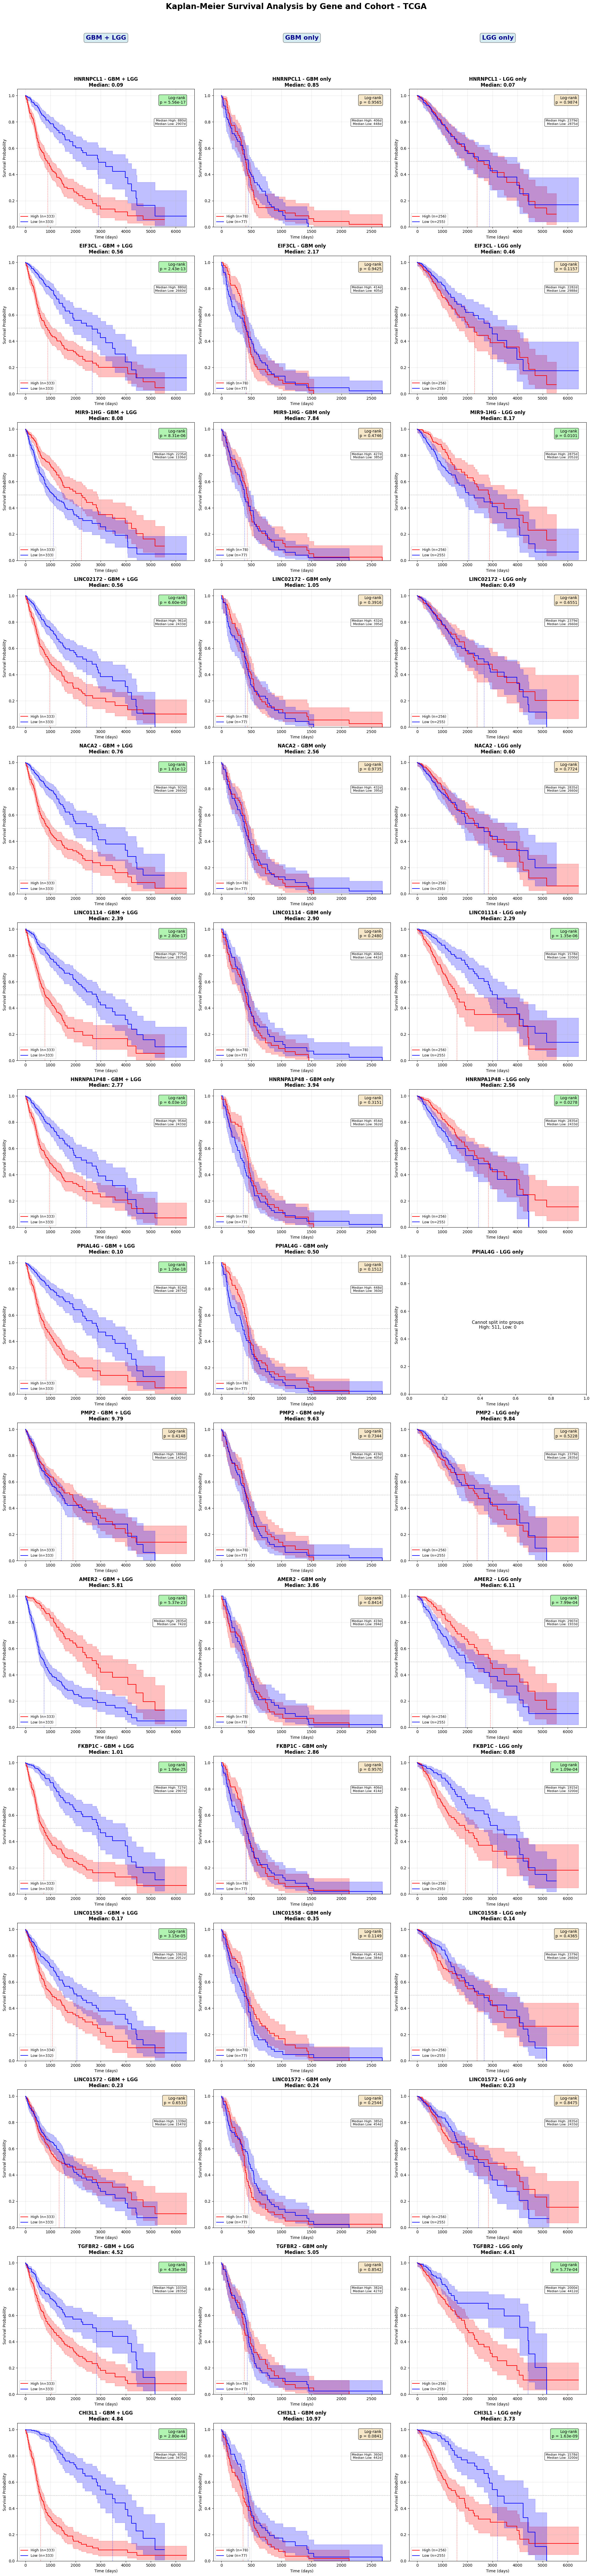

In [19]:
valid_genes = [g for g in genes_of_interest_ge if g in expr.columns]
n_genes = len(valid_genes)

cohorts = {
    'GBM + LGG': surv.index,                                     
    'GBM only': surv[surv['project'] == 'GBM'].index,                 
    'LGG only': surv[surv['project'] == 'LGG'].index,               
}

n_cols = 3
n_rows = n_genes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))

if n_genes == 1:
    axes = axes.reshape(1, -1)

results_summary = []

for row_idx, gene_name in enumerate(valid_genes):
    for col_idx, (cohort_label, patient_ids) in enumerate(cohorts.items()):
        
        ax = axes[row_idx, col_idx]
        
        # Subset expression and survival for this cohort
        expr_cohort = expr.loc[expr.index.isin(patient_ids)]
        surv_cohort = surv.loc[surv.index.isin(patient_ids), ['OS.time', 'OS']]
        
        # Ensure same patients in both
        common = expr_cohort.index.intersection(surv_cohort.index)
        expr_cohort = expr_cohort.loc[common]
        surv_cohort = surv_cohort.loc[common]
        
        p_val, cutoff_label, median_high, median_low = plot_km_curve(
            expr_cohort, surv_cohort, gene_name, 
            cohort_label=cohort_label, method='median', ax=ax
        )

        results_summary.append({
            'Gene': gene_name,
            'Cohort': cohort_label,
            'n_patients': len(common),
            'p_value': p_val,
            'cutoff': cutoff_label,
            'median_high': median_high,
            'median_low': median_low
        })

# Add column headers
for col_idx, cohort_label in enumerate(cohorts.keys()):
    axes[0, col_idx].annotate(
        cohort_label, 
        xy=(0.5, 1.35), xycoords='axes fraction',
        fontsize=16, fontweight='bold', ha='center', va='bottom',
        color='darkblue',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5)
    )

fig.suptitle('Kaplan-Meier Survival Analysis by Gene and Cohort - TCGA', 
             fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KM_grid_genes_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
for result in results_summary:
    print(result)

{'Gene': 'HNRNPCL1', 'Cohort': 'GBM + LGG', 'n_patients': 666, 'p_value': 5.559140280979957e-17, 'cutoff': 'Median: 0.09', 'median_high': 880.0, 'median_low': 2907.0}
{'Gene': 'HNRNPCL1', 'Cohort': 'GBM only', 'n_patients': 155, 'p_value': 0.9565393761166423, 'cutoff': 'Median: 0.85', 'median_high': 406.0, 'median_low': 448.0}
{'Gene': 'HNRNPCL1', 'Cohort': 'LGG only', 'n_patients': 511, 'p_value': 0.9874042868908242, 'cutoff': 'Median: 0.07', 'median_high': 2379.0, 'median_low': 2875.0}
{'Gene': 'EIF3CL', 'Cohort': 'GBM + LGG', 'n_patients': 666, 'p_value': 2.4322710089324364e-13, 'cutoff': 'Median: 0.56', 'median_high': 880.0, 'median_low': 2660.0}
{'Gene': 'EIF3CL', 'Cohort': 'GBM only', 'n_patients': 155, 'p_value': 0.9424687794942779, 'cutoff': 'Median: 2.17', 'median_high': 414.0, 'median_low': 405.0}
{'Gene': 'EIF3CL', 'Cohort': 'LGG only', 'n_patients': 511, 'p_value': 0.11571777833350247, 'cutoff': 'Median: 0.46', 'median_high': 2282.0, 'median_low': 2988.0}
{'Gene': 'MIR9-1HG

# DNA Methylation

In [3]:
probes_of_interest = ['cg19081101', 'cg03349020', 'cg05447100', 'cg15171154', 'cg05935571', 'cg04937416', 'cg04276626']
methylation_df = pd.read_csv('./UCSC_TCGA_Data_Clean/BN/dna_aggregated_clean.tsv', sep='\t', index_col=0, header=0).T
methylation_df = methylation_df[probes_of_interest]

# Join all survival data WITH project info
STUDY_PROJECTS = ['GBM', 'LGG']
survival_dfs = []
for project in STUDY_PROJECTS:
    df = pd.read_csv(f'./UCSC_TCGA_Data/Survival/TCGA-{project}', sep='\t')
    df['project'] = project
    survival_dfs.append(df)
survival_data = pd.concat(survival_dfs, ignore_index=True)

survival_data['_PATIENT'] = survival_data['_PATIENT'].str[:12]
survival_data = survival_data.drop_duplicates(subset='_PATIENT', keep='first')
survival_data = survival_data.set_index('_PATIENT')

common_patients = methylation_df.index.intersection(survival_data.index)
print(f"Common patients: {len(common_patients)}")

meth = methylation_df.loc[common_patients]
surv = survival_data.loc[common_patients, ['OS.time', 'OS', 'project']].copy()  

surv = surv.dropna(subset=['OS.time', 'OS'])
surv = surv[surv['OS.time'] > 0]
meth = meth.loc[surv.index]

print(f"Total patients: {len(surv)}")
print(f"GBM: {(surv['project'] == 'GBM').sum()}")
print(f"LGG: {(surv['project'] == 'LGG').sum()}")


Common patients: 648
Total patients: 648
GBM: 137
LGG: 511


In [22]:
# ============================================================
# 5. KM FUNCTION FOR METHYLATION (Beta values)
# ============================================================
def plot_km_curve_methylation(meth_data, surv_data, probe_id, probe_label=None,
                               cohort_label='All', method='median', ax=None):
    """
    Plot KM curve for a single methylation probe.
    
    Parameters:
    -----------
    meth_data : DataFrame - methylation matrix (patients x probes), beta values
    surv_data : DataFrame - survival data with OS.time and OS columns
    probe_id : str - probe ID (e.g., 'cg12345678')
    probe_label : str - label for the probe (e.g., 'cg12345678 (MGMT promoter)')
    cohort_label : str - cohort name
    method : str - 'median' or 'quartile'
    ax : matplotlib axis
    """
    
    if probe_label is None:
        probe_label = probe_id
    
    probe_values = meth_data[probe_id].copy()
    
    combined = pd.DataFrame({
        'methylation': probe_values,
        'OS_time': surv_data['OS.time'],
        'OS_status': surv_data['OS']
    }).dropna()
    
    combined['methylation'] = pd.to_numeric(combined['methylation'], errors='coerce')
    combined['OS_time'] = pd.to_numeric(combined['OS_time'], errors='coerce')
    combined['OS_status'] = pd.to_numeric(combined['OS_status'], errors='coerce')
    combined = combined.dropna()
    combined = combined[combined['OS_time'] > 0]
    
    # Check sample size
    if len(combined) < 10:
        if ax is not None:
            ax.text(0.5, 0.5, f'Insufficient data\nn={len(combined)}',
                    transform=ax.transAxes, ha='center', va='center', fontsize=11)
            ax.set_title(f'{probe_label}\n{cohort_label}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Time (days)', fontsize=10)
            ax.set_ylabel('Survival Probability', fontsize=10)
        return np.nan
    
    # Stratify
    if method == 'median':
        cutoff = combined['methylation'].median()
        
        n_above = (combined['methylation'] > cutoff).sum()
        n_below = (combined['methylation'] < cutoff).sum()
        
        if n_above == 0 and n_below == 0:
            if ax is not None:
                ax.text(0.5, 0.5, f'All values identical\n(β={cutoff:.3f})',
                        transform=ax.transAxes, ha='center', va='center', fontsize=11)
                ax.set_title(f'{probe_label}\n{cohort_label}', fontsize=11, fontweight='bold')
                ax.set_xlabel('Time (days)', fontsize=10)
                ax.set_ylabel('Survival Probability', fontsize=10)
            return np.nan
        
        # Use > to handle ties at median
        combined['group'] = np.where(combined['methylation'] > cutoff, 'Hyper', 'Hypo')
        
        # If one group is empty, flip the operator
        if (combined['group'] == 'Hyper').sum() == 0:
            combined['group'] = np.where(combined['methylation'] >= cutoff, 'Hyper', 'Hypo')
        elif (combined['group'] == 'Hypo').sum() == 0:
            combined['group'] = np.where(combined['methylation'] > cutoff, 'Hyper', 'Hypo')
            
        n_hyper = (combined['group'] == 'Hyper').sum()
        n_hypo = (combined['group'] == 'Hypo').sum()
        cutoff_label = f"Median β: {cutoff:.3f}"
        
    elif method == 'quartile':
        q25 = combined['methylation'].quantile(0.25)
        q75 = combined['methylation'].quantile(0.75)
        combined = combined[
            (combined['methylation'] <= q25) | (combined['methylation'] >= q75)
        ]
        combined['group'] = np.where(
            combined['methylation'] >= q75, 'Hyper (Q4)', 'Hypo (Q1)'
        )
        cutoff_label = f"Q1: {q25:.3f}, Q4: {q75:.3f}"
    
    mask_hyper = combined['group'].str.contains('Hyper')
    mask_hypo = combined['group'].str.contains('Hypo')
    
    if mask_hyper.sum() < 2 or mask_hypo.sum() < 2:
        if ax is not None:
            ax.text(0.5, 0.5, f'Too few per group\nHyper:{mask_hyper.sum()}, Hypo:{mask_hypo.sum()}',
                    transform=ax.transAxes, ha='center', va='center', fontsize=11)
            ax.set_title(f'{probe_label}\n{cohort_label}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Time (days)', fontsize=10)
            ax.set_ylabel('Survival Probability', fontsize=10)
        return np.nan
    
    T_hyper = combined.loc[mask_hyper, 'OS_time'].astype(float)
    E_hyper = combined.loc[mask_hyper, 'OS_status'].astype(float)
    T_hypo = combined.loc[mask_hypo, 'OS_time'].astype(float)
    E_hypo = combined.loc[mask_hypo, 'OS_status'].astype(float)
    
    # Log-rank test
    try:
        results = logrank_test(T_hyper, T_hypo, event_observed_A=E_hyper, event_observed_B=E_hypo)
        p_value = results.p_value
    except Exception as e:
        print(f"⚠️ Log-rank failed for {probe_id} in {cohort_label}: {e}")
        p_value = np.nan
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    try:
        kmf = KaplanMeierFitter()
        
        # Hypermethylated (red = bad typically)
        kmf.fit(T_hyper, event_observed=E_hyper, label=f'Hyper (n={mask_hyper.sum()})')
        kmf.plot_survival_function(ax=ax, color='red', ci_show=True)
        
        # Hypomethylated (blue)
        kmf.fit(T_hypo, event_observed=E_hypo, label=f'Hypo (n={mask_hypo.sum()})')
        kmf.plot_survival_function(ax=ax, color='blue', ci_show=True)
    except Exception as e:
        print(f"⚠️ KM fitting failed for {probe_id} in {cohort_label}: {e}")
        ax.text(0.5, 0.5, 'KM fitting error',
                transform=ax.transAxes, ha='center', va='center', fontsize=11)
        return np.nan

    kmf_hyper = KaplanMeierFitter()
    kmf_hyper.fit(T_hyper, event_observed=E_hyper)
    median_hyper = kmf_hyper.median_survival_time_

    kmf_hypo = KaplanMeierFitter()
    kmf_hypo.fit(T_hypo, event_observed=E_hypo)
    median_hypo = kmf_hypo.median_survival_time_

    # Horizontal dashed line at 0.5
    ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    # Vertical drop lines for each group (only if median is reached)
    median_texts = []
    if np.isfinite(median_hyper):
        ax.vlines(x=median_hyper, ymin=0, ymax=0.5,
                  color='red', linestyle='--', linewidth=0.8, alpha=0.6)
        median_texts.append(f'Median Hyper: {median_hyper:.0f}d')
    else:
        median_texts.append('Median Hyper: NR')

    if np.isfinite(median_hypo):
        ax.vlines(x=median_hypo, ymin=0, ymax=0.5,
                  color='blue', linestyle='--', linewidth=0.8, alpha=0.6)
        median_texts.append(f'Median Hypo: {median_hypo:.0f}d')
    else:
        median_texts.append('Median Hypo: NR')

    # Add median survival text box
    ax.text(0.95, 0.78, '\n'.join(median_texts),
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Title
    ax.set_title(f'{probe_label}\n{cohort_label} | {cutoff_label}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel('Survival Probability', fontsize=10)
    
    # P-value
    if not np.isnan(p_value):
        p_text = f'p = {p_value:.2e}' if p_value < 0.001 else f'p = {p_value:.4f}'
        box_color = 'lightgreen' if p_value < 0.05 else 'wheat'
    else:
        p_text = 'p = N/A'
        box_color = 'lightgrey'
    
    ax.text(0.95, 0.95, f'Log-rank\n{p_text}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.7))
    
    ax.legend(loc='lower left', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    
    return p_value, median_hypo, median_hyper, cutoff_label

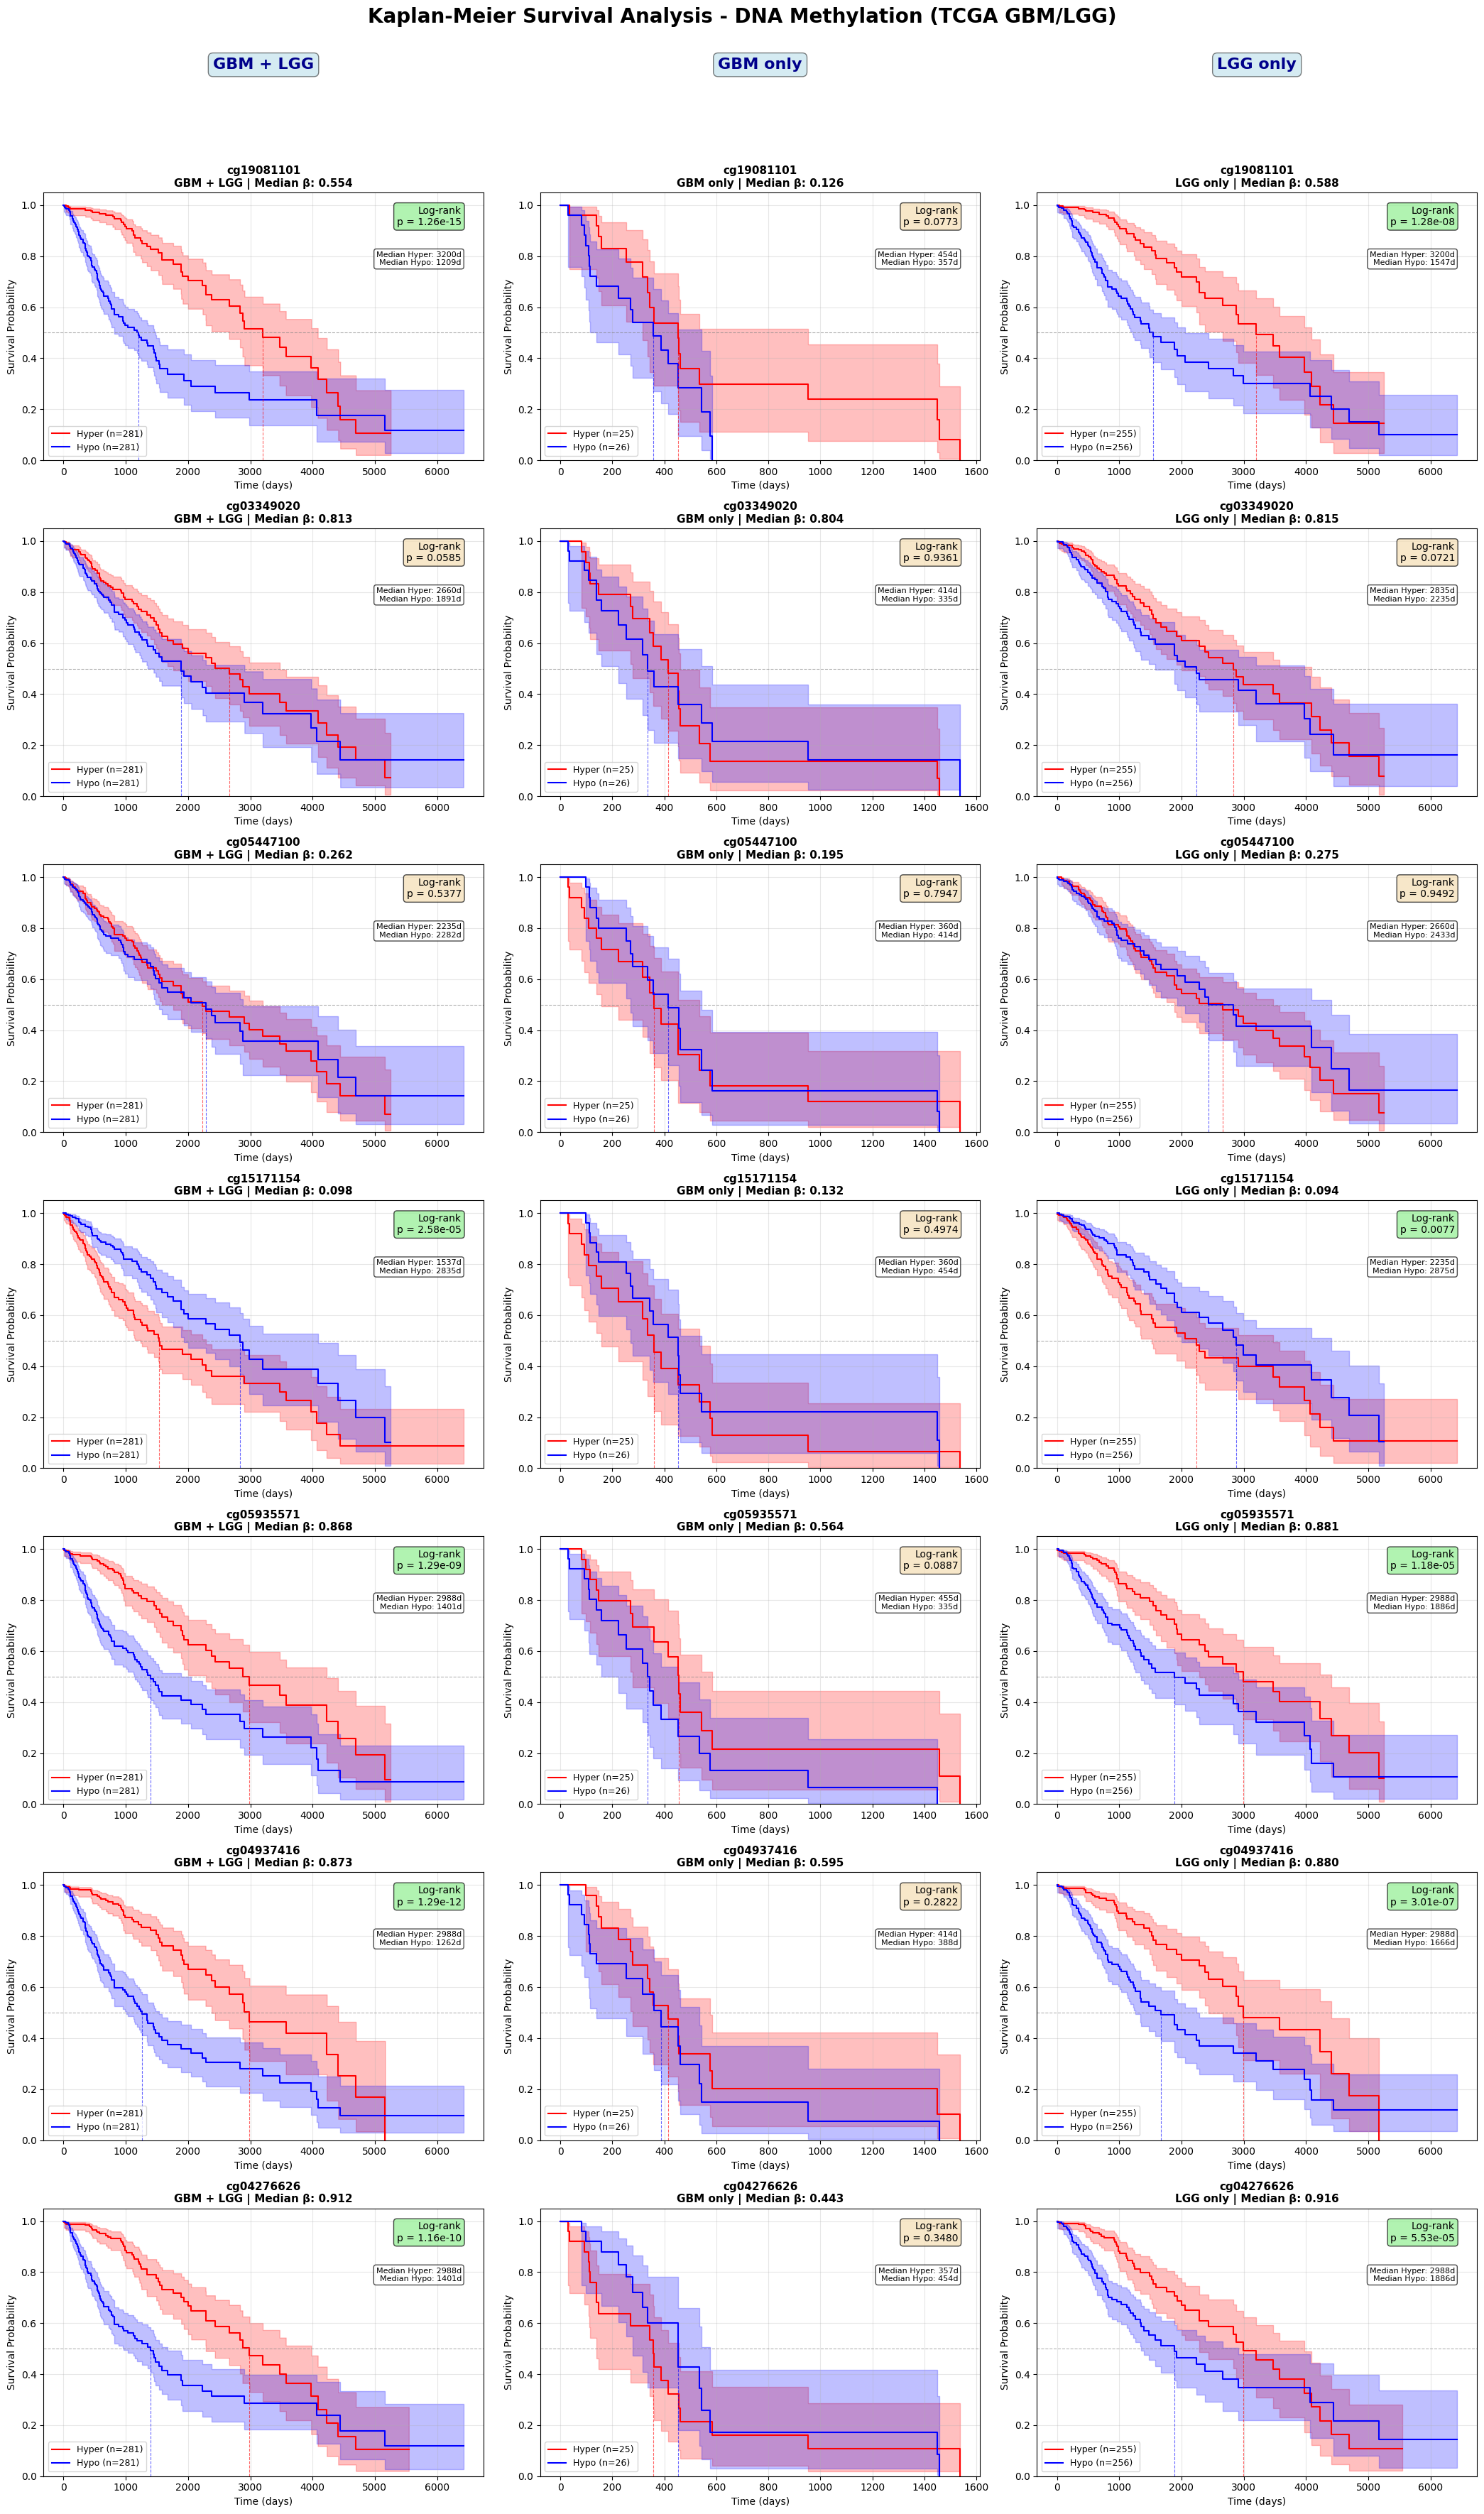

In [ ]:
n_probes = len(probes_of_interest)

cohorts = {
    'GBM + LGG': surv.index,
    'GBM only': surv[surv['project'] == 'GBM'].index,
    'LGG only': surv[surv['project'] == 'LGG'].index,
}

n_cols = 3
n_rows = n_probes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
if n_probes == 1:
    axes = axes.reshape(1, -1)

results_summary = []

for row_idx, probe_id in enumerate(probes_of_interest):
    
    for col_idx, (cohort_label, patient_ids) in enumerate(cohorts.items()):
        
        ax = axes[row_idx, col_idx]
        
        meth_cohort = meth.loc[meth.index.isin(patient_ids)]
        surv_cohort = surv.loc[surv.index.isin(patient_ids), ['OS.time', 'OS']]
        
        common = meth_cohort.index.intersection(surv_cohort.index)
        meth_cohort = meth_cohort.loc[common]
        surv_cohort = surv_cohort.loc[common]
        
        p_val, median_hypo, median_hyper, cutoff_label = plot_km_curve_methylation(
            meth_cohort, surv_cohort, probe_id,
            probe_label=probe_id,
            cohort_label=cohort_label, method='median', ax=ax
        )
        
        results_summary.append({
            'Probe': probe_id,
            'Cohort': cohort_label,
            'n_patients': len(common),
            'p_value': p_val,
            'cutoff': cutoff_label,
            'median_hypo': median_hypo,
            'median_hyper': median_hyper
        })

# Column headers
for col_idx, cohort_label in enumerate(cohorts.keys()):
    axes[0, col_idx].annotate(
        cohort_label,
        xy=(0.5, 1.45), xycoords='axes fraction',
        fontsize=16, fontweight='bold', ha='center', va='bottom',
        color='darkblue',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5)
    )

fig.suptitle('Kaplan-Meier Survival Analysis - DNA Methylation (TCGA GBM/LGG)',
             fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KM_methylation_grid_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
for result in results_summary:
    print(result)

{'Probe': 'cg19081101', 'Cohort': 'GBM + LGG', 'n_patients': 562, 'p_value': 1.255947729070154e-15, 'cutoff': 'Median β: 0.554', 'median_hypo': 1209.0, 'median_hyper': 3200.0}
{'Probe': 'cg19081101', 'Cohort': 'GBM only', 'n_patients': 51, 'p_value': 0.07727148673895377, 'cutoff': 'Median β: 0.126', 'median_hypo': 357.0, 'median_hyper': 454.0}
{'Probe': 'cg19081101', 'Cohort': 'LGG only', 'n_patients': 511, 'p_value': 1.275102996882659e-08, 'cutoff': 'Median β: 0.588', 'median_hypo': 1547.0, 'median_hyper': 3200.0}
{'Probe': 'cg03349020', 'Cohort': 'GBM + LGG', 'n_patients': 562, 'p_value': 0.058533327020376585, 'cutoff': 'Median β: 0.813', 'median_hypo': 1891.0, 'median_hyper': 2660.0}
{'Probe': 'cg03349020', 'Cohort': 'GBM only', 'n_patients': 51, 'p_value': 0.9360549077062157, 'cutoff': 'Median β: 0.804', 'median_hypo': 335.0, 'median_hyper': 414.0}
{'Probe': 'cg03349020', 'Cohort': 'LGG only', 'n_patients': 511, 'p_value': 0.07207327196399069, 'cutoff': 'Median β: 0.815', 'median_h